# Import Libraries

In [1]:
import os
import math
import time
import random
import shutil
import itertools
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from multiprocessing import Pool, cpu_count
from tqdm import tqdm, trange

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Network Definition

#### Neuron number and precision in each layer listed in this area for the MLP used in MNIST classification

In [2]:
neuron_num_FC_layer_0 = 1024
neuron_num_FC_layer_1 = 1024
neuron_num_FC_layer_2 = 1024
neuron_num_OUT_layer  = 10

#### Hyperparameters setting here.

In [3]:
epochs = 100
batch_sizes = [64]
dropout_rates = [0.0, 0.05, 0.1]
lr_max_pool = [0.001, 0.0005]
lr_min_pool = [0.00001, 0.000001]

#### GPU selection. After decided which GPU to train, don't change it before completing the training

In [4]:
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

In [5]:
GPU_device = "cuda:1"

#### Training date output folder path, for different network model setting, please change the name of save_path

In [6]:
save_path     = "LFC_float"

project_root  = os.path.abspath(".")
dataset_root  = os.path.join(project_root, "dataset")
train_root    = os.path.join(project_root, "train")
output_root   = os.path.join(train_root, save_path)
report_root  = os.path.join(project_root, "report")

print("Dataset Download Path: ", dataset_root, "\n")
print("Training Data Output Path: ", output_root, "\n")
print("Training Report Output Path: ", report_root)

os.makedirs(dataset_root, exist_ok=True)
os.makedirs(output_root, exist_ok=True)
os.makedirs(report_root, exist_ok=True)

Dataset Download Path:  /home/yuhao/project/new KAN/BiKA/experiment/MLP-like/MNIST/dataset 

Training Data Output Path:  /home/yuhao/project/new KAN/BiKA/experiment/MLP-like/MNIST/train/LFC_float 

Training Report Output Path:  /home/yuhao/project/new KAN/BiKA/experiment/MLP-like/MNIST/report


#### Following are the code to complete the network definition

In [7]:
input_length  = 28*28

hidden_0      = neuron_num_FC_layer_0
hidden_1      = neuron_num_FC_layer_1
hidden_2      = neuron_num_FC_layer_2

output_length = neuron_num_OUT_layer

In [8]:
class MLP(nn.Module):
    def __init__(self, dropout=0.5):
        super(MLP, self).__init__()
        
        self.fc0   = nn.Linear(input_length, hidden_0)
        self.bn0   = nn.BatchNorm1d(hidden_0)
        self.relu0 = nn.ReLU()
        self.drop0 = nn.Dropout(dropout)
        
        self.fc1   = nn.Linear(hidden_0, hidden_1)
        self.bn1   = nn.BatchNorm1d(hidden_1)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(dropout)
        
        self.fc2   = nn.Linear(hidden_1, hidden_2)
        self.bn2   = nn.BatchNorm1d(hidden_2)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(dropout)
        
        self.out   = nn.Linear(hidden_2, output_length)

    def forward(self, x):
        
        out = x.reshape(x.shape[0], -1)
        out = self.drop0(self.relu0(self.bn0(self.fc0(out))))
        out = self.drop1(self.relu1(self.bn1(self.fc1(out))))
        out = self.drop2(self.relu2(self.bn2(self.fc2(out))))
        out = self.out(out)
        
        return out

# Random Seed Utility

In [9]:
def set_random_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# Define Dataloader

In [10]:
test_batch_size = 4096

In [11]:
def get_dataloaders(batch_size):    
    train_dataset = datasets.MNIST(  dataset_root, 
                                     train=True, 
                                     download=True,
                                     transform=transforms.Compose
                                     ([
                                         transforms.ToTensor(),
                                         transforms.Normalize((0.5,), (0.5,))
                                     ])
                                  )
    test_dataset  = datasets.MNIST( dataset_root, 
                                    train=False, 
                                    download=True,
                                    transform=transforms.Compose
                                    ([
                                         transforms.ToTensor(),
                                         transforms.Normalize((0.5,), (0.5,))
                                    ])
                                  )
    val_size = int(0.2 * len(train_dataset))
    train_size = len(train_dataset) - val_size
    train_set, val_set = random_split(train_dataset, [train_size, val_size])
    return (
        DataLoader(
            train_set,
            batch_size=batch_size,
            shuffle=True,
            num_workers=12,
            pin_memory=True,
            persistent_workers=True,
            prefetch_factor=4,
        ),
        DataLoader(
            val_set,
            batch_size=batch_size,
            shuffle=False,
            num_workers=12,
            pin_memory=True,
            persistent_workers=True,
            prefetch_factor=4,
        ),
        DataLoader(test_dataset, batch_size=test_batch_size),
    )

# Evaluation Pipeline

In [12]:
def evaluate(model, criterion, device, loader, show_progress=False):
    model.eval()
    loss_total, correct, total = 0, 0, 0

    with torch.no_grad():
        for x, y in tqdm(loader, desc="Evaluation", leave=True, disable=not show_progress):
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)

            loss_total += loss.item() * x.size(0)
            _, pred = out.max(1)
            correct += (pred == y).sum().item()
            total += x.size(0)

    return loss_total / total, correct / total

# Plot Training Loss and Accuracy

In [13]:
def plot_train(history, save_dir):
    # Plot and show
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.legend()
    plt.title("Loss")

    plt.subplot(1, 2, 2)
    plt.plot(history["train_acc"], label="Train Acc")
    plt.plot(history["val_acc"], label="Val Acc")
    plt.legend()
    plt.title("Accuracy")
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "training_plot.png"))
    plt.show()

# Training, Validation, and Testing Pipeline

In [14]:
def train_validate_test(config, save_dir):
    set_random_seed()
    os.makedirs(save_dir, exist_ok=True)
    log_file = os.path.join(save_dir, "training_log.txt")
    resume_path = os.path.join(save_dir, "checkpoint.pth")
    csv_log_path = os.path.join(save_dir, "training_log.csv")
    with open(csv_log_path, "a") as f:
        if os.path.getsize(csv_log_path) == 0:
            f.write("Epoch,Learning Rate,Train Loss,Train Acc,Val Loss,Val Acc,Epoch Time,Train Time,Val Time\n")

    epochs, batch_size, lr_max, lr_min, dropout = config
    train_loader, val_loader, test_loader = get_dataloaders(batch_size)
    device = torch.device(GPU_device if torch.cuda.is_available() else "cpu")
    model = MLP(dropout=dropout).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr_max)

    start_epoch = 0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "epoch_time": [], "train_time": [], "val_time": []}

    if os.path.exists(resume_path):
        ckpt = torch.load(resume_path, map_location="cpu")
        model.load_state_dict(ckpt["model_state"])
        model.to(device)
        optimizer.load_state_dict(ckpt["optimizer_state"])
        for state in optimizer.state.values():
            for k, v in state.items():
                if torch.is_tensor(v):
                    state[k] = v.to(device)
        history = ckpt["history"]
        start_epoch = ckpt["epoch"] + 1
        print(f"🔄 Resuming from epoch {start_epoch}")
    else:
        with open(log_file, "w") as f:
            f.write("Training started\n")

    # Training Loop
    t = trange(start_epoch, epochs, desc="Training", leave=True)
    for epoch in t:
        epoch_start = time.time()
        model.train()
        lr = lr_min + 0.5 * (lr_max - lr_min) * (1 + math.cos(math.pi * epoch / epochs))
        for g in optimizer.param_groups:
            g["lr"] = lr

        train_start = time.time()
        train_loss, correct, total = 0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * x.size(0)
            _, pred = out.max(1)
            correct += (pred == y).sum().item()
            total += x.size(0)
        train_time = time.time() - train_start

        val_start = time.time()
        val_loss, val_acc = evaluate(model, criterion, device, val_loader)
        val_time = time.time() - val_start
        train_loss /= total
        train_acc = correct / total
        epoch_time = time.time() - epoch_start
        
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["epoch_time"].append(epoch_time/60)
        history["train_time"].append(train_time/60)
        history["val_time"].append(val_time/60)

        log_line = (f"Epoch {epoch+1}/{epochs} - LR: {lr:.6f} | "
                    f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
                    f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f} | "
                    f"Epoch Time: {epoch_time/60:.2f}, Train Time: {train_time/60:.2f}, Val Time: {val_time/60:.2f}")
        
        with open(log_file, "a") as f:
            f.write(log_line + "\n")

        
        with open(os.path.join(save_dir, "training_log.csv"), "a") as f:
            f.write(f"{epoch+1},{lr:.6f},{train_loss:.4f},{train_acc:.4f},{val_loss:.4f},{val_acc:.4f},{epoch_time/60:.4f},{train_time/60:.4f},{val_time/60:.4f}\n")

        t.set_description("| LR: %.6f | Train Acc: %.4f | Val Acc: %.4f | Epoch Time: %.2f | " % (lr, train_acc, val_acc, epoch_time/60))
        t.refresh()

        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "history": history
        }, resume_path)

    # Plot and show the training history
    plot_train(history, save_dir)

    # Test the original trained model
    original_test_loss, original_test_acc = evaluate(model, criterion, device, test_loader)
    final_line = f"Original Model Final Test Loss: {original_test_loss:.4f} Accuracy: {original_test_acc:.4f}"
    print(final_line)
    with open(log_file, "a") as f:
        f.write("Training completed\n")
        f.write(final_line + "\n")

    # Save the trained model
    torch.save(model.state_dict(), os.path.join(save_dir, "final_model.pth"))
    with open(log_file, "a") as f:
        f.write(final_line + "\n")
    print("\n")

    return original_test_acc, resume_path

# Hyperparameter Searching for Network Training and Testing

In [15]:
def Hyperparameter_searching(epochs, batch_sizes, lr_max_pool, lr_min_pool, dropout_rates):
    
    epochs = epochs
    batch_sizes = batch_sizes
    lr_max_pool = lr_max_pool
    lr_min_pool = lr_min_pool
    
    all_runs = [
        f"batch{bs}_lr_max_{lr_max}_min_{lr_min}_dp{dropout}"
        for bs, lr_max, lr_min, dropout in itertools.product(batch_sizes, lr_max_pool, lr_min_pool, dropout_rates)
    ]
    
    completed_runs = []
    for run in all_runs:
        log_path = os.path.join(output_root, run, "training_log.txt")
        if os.path.exists(log_path):
            with open(log_path, "r") as f:
                if any("Training completed" in line for line in f):
                    completed_runs.append(run)
    
    if len(completed_runs) == len(all_runs):
        print("✅ All combinations completed. No retraining will be started.")
        print("ℹ️ If you want to retrain from scratch, please manually delete the previous training records/checkpoints.")
        completed_runs = []
    
    results = []
    for batch_size, lr_max, lr_min, dropout in itertools.product(batch_sizes, lr_max_pool, lr_min_pool, dropout_rates):
        run_name = f"batch{batch_size}_lr_max_{lr_max}_min_{lr_min}_dp{dropout}"
        save_dir = os.path.join(output_root, run_name)
    
        if run_name in completed_runs:
            print(f"✅ Skipping {run_name}")
            with open(os.path.join(save_dir, "training_log.txt")) as f:
                for line in f:
                    if "Final Test Loss" in line:
                        acc = float(line.strip().split()[-1])
                        results.append((run_name, acc))
            continue
    
        print(f"🚀 Running: {run_name}")
        acc, resume_path = train_validate_test([epochs, batch_size, lr_max, lr_min, dropout], save_dir)
        results.append((run_name, acc, epochs, batch_size, lr_max, lr_min, dropout, resume_path))
    
    results.sort(key=lambda x: x[1], reverse=True)
    best_config, best_acc, best_epochs, best_batch_size, best_lr_max, best_lr_min, best_dropout, best_resume_path = results[0]
    
    with open(os.path.join(report_root, save_path+"_report.csv"), "w") as f:
        f.write("Epoch,Batch Size,LR_max,LR_min,Dropout,Accuracy\n")
        for name, acc, epoch, batch_size, lr_max, lr_min, dropout, resume_path in results:
            f.write(f"{epoch},{batch_size},{lr_max:.4f},{lr_min:.6f},{dropout:.4f},{acc:.4f}\n")
            
    return best_epochs, best_batch_size, best_lr_max, best_lr_min, best_dropout, best_resume_path

In [16]:
def best_evaluation(epochs, batch_size, lr_max, lr_min, dropout, resume_path):
    set_random_seed()

    epochs, batch_size, lr_max, lr_min, dropout = epochs, batch_size, lr_max, lr_min, dropout
    train_loader, val_loader, test_loader = get_dataloaders(batch_size)
    device = torch.device(GPU_device if torch.cuda.is_available() else "cpu")
    model = MLP(dropout=dropout).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr_max)

    if os.path.exists(resume_path):
        ckpt = torch.load(resume_path, map_location="cpu")
        model.load_state_dict(ckpt["model_state"])
        model.to(device)
        optimizer.load_state_dict(ckpt["optimizer_state"])
        for state in optimizer.state.values():
            for k, v in state.items():
                if torch.is_tensor(v):
                    state[k] = v.to(device)
        history = ckpt["history"]
        print("Best model loaded.")
    else:
        print("Best model lost.")

    # Test the original trained model
    original_test_loss, original_test_acc = evaluate(model, criterion, device, test_loader, show_progress=True)
    final_line = (
        f"Best Original Model Final Test Loss: {original_test_loss:.4f} "
        f"Acc: {original_test_acc:.4f} "
    )
    print(final_line)
    print("\n")

    with open(os.path.join(report_root, save_path + "_best_eval.csv"), "w") as f:
        f.write("Epoch,Batch Size,LR_max,LR_min,Dropout,Acc,Loss\n")
        f.write(f"{epochs},{batch_size},{lr_max:.4f},{lr_min:.6f},{dropout:.4f},{original_test_acc:.4f},{original_test_loss:.4f}\n")

🚀 Running: batch64_lr_max_0.001_min_1e-05_dp0.0


Training:   0%|                                                                                                                                                                                                     | 0/100 [00:00<?, ?it/s]

| LR: 0.001000 | Train Acc: 0.9377 | Val Acc: 0.9630 | Epoch Time: 0.11 | :   0%|                                                                                                                                   | 0/100 [00:06<?, ?it/s]

| LR: 0.001000 | Train Acc: 0.9377 | Val Acc: 0.9630 | Epoch Time: 0.11 | :   0%|                                                                                                                                   | 0/100 [00:06<?, ?it/s]

| LR: 0.001000 | Train Acc: 0.9377 | Val Acc: 0.9630 | Epoch Time: 0.11 | :   1%|█▏                                                                                                                         | 1/100 [00:06<11:22,  6.89s/it]

...

| LR: 0.000011 | Train Acc: 1.0000 | Val Acc: 0.9863 | Epoch Time: 0.07 | :  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊ | 99/100 [07:04<00:04,  4.25s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.9862 | Epoch Time: 0.07 | :  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊ | 99/100 [07:08<00:04,  4.25s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.9862 | Epoch Time: 0.07 | :  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊ | 99/100 [07:08<00:04,  4.25s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.9862 | Epoch Time: 0.07 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [07:08<00:00,  4.21s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.9862 | Epoch Time: 0.07 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [07:08<00:00,  4.28s/it]

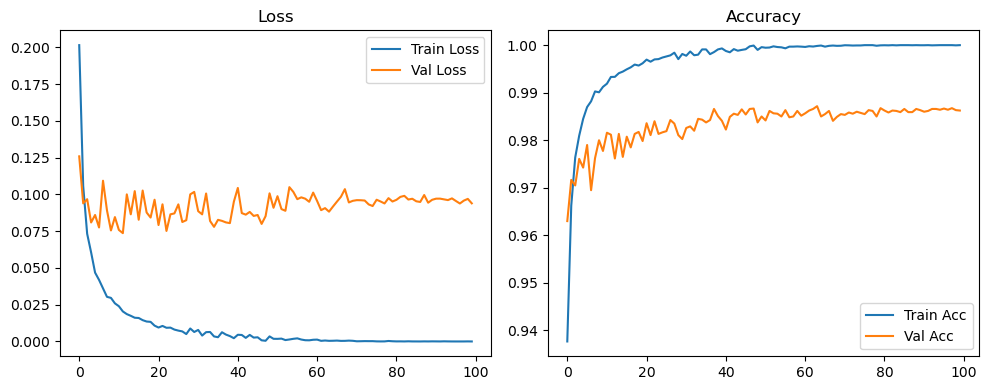

Original Model Final Test Loss: 0.0964 Accuracy: 0.9872




🚀 Running: batch64_lr_max_0.001_min_1e-05_dp0.05


Training:   0%|                                                                                                                                                                                                     | 0/100 [00:00<?, ?it/s]

| LR: 0.001000 | Train Acc: 0.9358 | Val Acc: 0.9575 | Epoch Time: 0.10 | :   0%|                                                                                                                                   | 0/100 [00:06<?, ?it/s]

| LR: 0.001000 | Train Acc: 0.9358 | Val Acc: 0.9575 | Epoch Time: 0.10 | :   0%|                                                                                                                                   | 0/100 [00:06<?, ?it/s]

...

| LR: 0.000011 | Train Acc: 1.0000 | Val Acc: 0.9867 | Epoch Time: 0.07 | :  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊ | 99/100 [07:20<00:04,  4.47s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.9870 | Epoch Time: 0.07 | :  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊ | 99/100 [07:25<00:04,  4.47s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.9870 | Epoch Time: 0.07 | :  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊ | 99/100 [07:25<00:04,  4.47s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.9870 | Epoch Time: 0.07 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [07:25<00:00,  4.47s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.9870 | Epoch Time: 0.07 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [07:25<00:00,  4.45s/it]

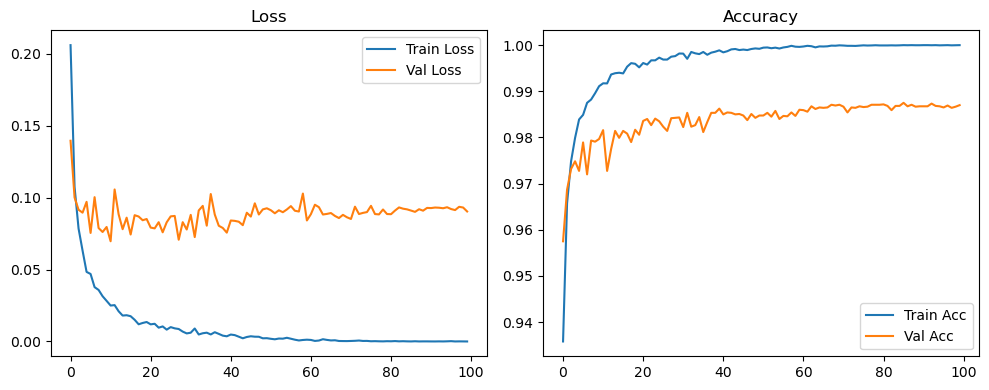

Original Model Final Test Loss: 0.0845 Accuracy: 0.9879




🚀 Running: batch64_lr_max_0.001_min_1e-05_dp0.1


Training:   0%|                                                                                                                                                                                                     | 0/100 [00:00<?, ?it/s]

| LR: 0.001000 | Train Acc: 0.9341 | Val Acc: 0.9587 | Epoch Time: 0.10 | :   0%|                                                                                                                                   | 0/100 [00:06<?, ?it/s]

| LR: 0.001000 | Train Acc: 0.9341 | Val Acc: 0.9587 | Epoch Time: 0.10 | :   0%|                                                                                                                                   | 0/100 [00:06<?, ?it/s]

...

| LR: 0.000011 | Train Acc: 1.0000 | Val Acc: 0.9875 | Epoch Time: 0.07 | :  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊ | 99/100 [07:21<00:04,  4.51s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.9872 | Epoch Time: 0.07 | :  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊ | 99/100 [07:25<00:04,  4.51s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.9872 | Epoch Time: 0.07 | :  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊ | 99/100 [07:25<00:04,  4.51s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.9872 | Epoch Time: 0.07 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [07:25<00:00,  4.47s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.9872 | Epoch Time: 0.07 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [07:25<00:00,  4.46s/it]

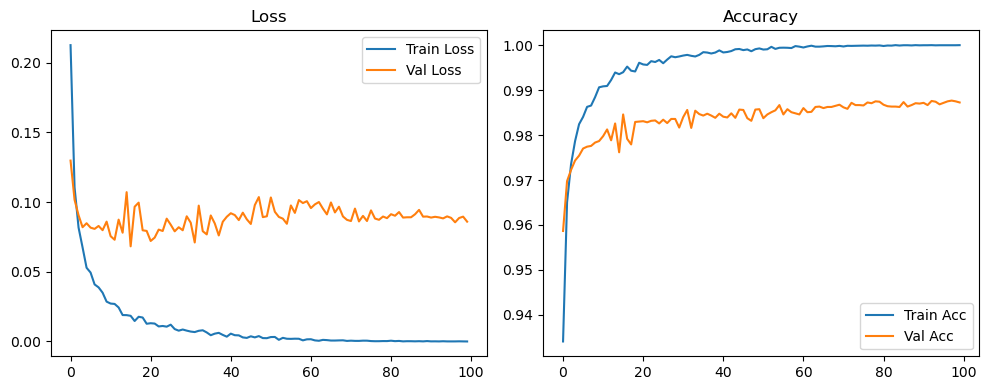

Original Model Final Test Loss: 0.0889 Accuracy: 0.9881




🚀 Running: batch64_lr_max_0.001_min_1e-06_dp0.0


Training:   0%|                                                                                                                                                                                                     | 0/100 [00:00<?, ?it/s]

| LR: 0.001000 | Train Acc: 0.9377 | Val Acc: 0.9630 | Epoch Time: 0.10 | :   0%|                                                                                                                                   | 0/100 [00:06<?, ?it/s]

| LR: 0.001000 | Train Acc: 0.9377 | Val Acc: 0.9630 | Epoch Time: 0.10 | :   0%|                                                                                                                                   | 0/100 [00:06<?, ?it/s]

...

| LR: 0.000002 | Train Acc: 1.0000 | Val Acc: 0.9862 | Epoch Time: 0.07 | :  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊ | 99/100 [07:03<00:04,  4.29s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9869 | Epoch Time: 0.07 | :  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊ | 99/100 [07:07<00:04,  4.29s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9869 | Epoch Time: 0.07 | :  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊ | 99/100 [07:07<00:04,  4.29s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9869 | Epoch Time: 0.07 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [07:07<00:00,  4.24s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9869 | Epoch Time: 0.07 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [07:07<00:00,  4.28s/it]

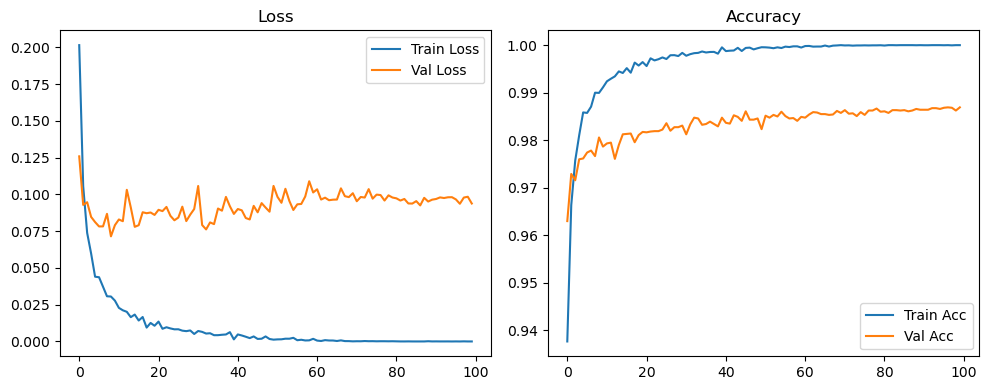

Original Model Final Test Loss: 0.0896 Accuracy: 0.9873




🚀 Running: batch64_lr_max_0.001_min_1e-06_dp0.05


Training:   0%|                                                                                                                                                                                                     | 0/100 [00:00<?, ?it/s]

| LR: 0.001000 | Train Acc: 0.9358 | Val Acc: 0.9575 | Epoch Time: 0.11 | :   0%|                                                                                                                                   | 0/100 [00:06<?, ?it/s]

| LR: 0.001000 | Train Acc: 0.9358 | Val Acc: 0.9575 | Epoch Time: 0.11 | :   0%|                                                                                                                                   | 0/100 [00:06<?, ?it/s]

...

| LR: 0.000002 | Train Acc: 1.0000 | Val Acc: 0.9874 | Epoch Time: 0.07 | :  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊ | 99/100 [07:23<00:04,  4.39s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9874 | Epoch Time: 0.08 | :  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊ | 99/100 [07:27<00:04,  4.39s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9874 | Epoch Time: 0.08 | :  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊ | 99/100 [07:27<00:04,  4.39s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9874 | Epoch Time: 0.08 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [07:27<00:00,  4.45s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9874 | Epoch Time: 0.08 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [07:27<00:00,  4.48s/it]

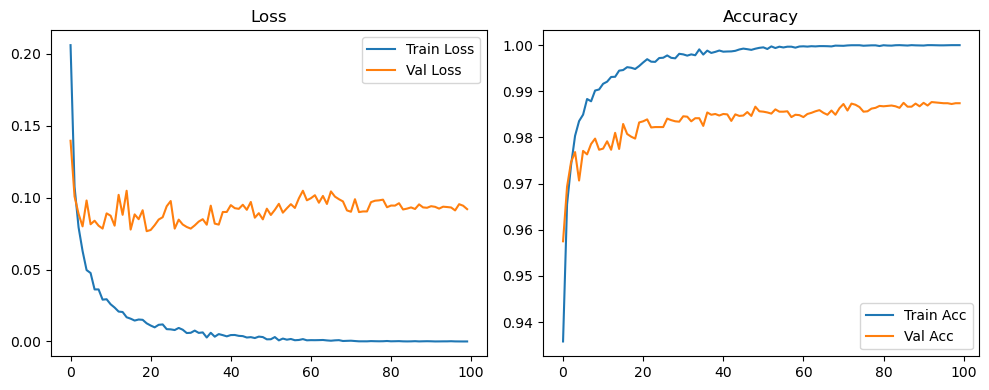

Original Model Final Test Loss: 0.0886 Accuracy: 0.9859




🚀 Running: batch64_lr_max_0.001_min_1e-06_dp0.1


Training:   0%|                                                                                                                                                                                                     | 0/100 [00:00<?, ?it/s]

| LR: 0.001000 | Train Acc: 0.9341 | Val Acc: 0.9587 | Epoch Time: 0.10 | :   0%|                                                                                                                                   | 0/100 [00:06<?, ?it/s]

| LR: 0.001000 | Train Acc: 0.9341 | Val Acc: 0.9587 | Epoch Time: 0.10 | :   0%|                                                                                                                                   | 0/100 [00:06<?, ?it/s]

...

| LR: 0.000002 | Train Acc: 1.0000 | Val Acc: 0.9868 | Epoch Time: 0.07 | :  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊ | 99/100 [07:13<00:04,  4.08s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9868 | Epoch Time: 0.07 | :  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊ | 99/100 [07:17<00:04,  4.08s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9868 | Epoch Time: 0.07 | :  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊ | 99/100 [07:17<00:04,  4.08s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9868 | Epoch Time: 0.07 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [07:17<00:00,  4.06s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9868 | Epoch Time: 0.07 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [07:17<00:00,  4.38s/it]

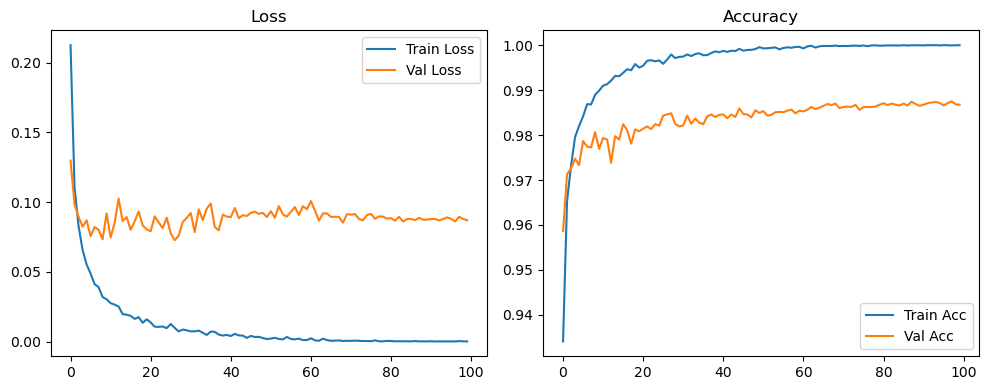

Original Model Final Test Loss: 0.0881 Accuracy: 0.9875




🚀 Running: batch64_lr_max_0.0005_min_1e-05_dp0.0


Training:   0%|                                                                                                                                                                                                     | 0/100 [00:00<?, ?it/s]

| LR: 0.000500 | Train Acc: 0.9431 | Val Acc: 0.9657 | Epoch Time: 0.10 | :   0%|                                                                                                                                   | 0/100 [00:05<?, ?it/s]

| LR: 0.000500 | Train Acc: 0.9431 | Val Acc: 0.9657 | Epoch Time: 0.10 | :   0%|                                                                                                                                   | 0/100 [00:05<?, ?it/s]

...

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.9870 | Epoch Time: 0.05 | :  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊ | 99/100 [06:29<00:02,  3.00s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.9872 | Epoch Time: 0.05 | :  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊ | 99/100 [06:32<00:02,  3.00s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.9872 | Epoch Time: 0.05 | :  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊ | 99/100 [06:32<00:02,  3.00s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.9872 | Epoch Time: 0.05 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [06:32<00:00,  2.93s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.9872 | Epoch Time: 0.05 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [06:32<00:00,  3.93s/it]

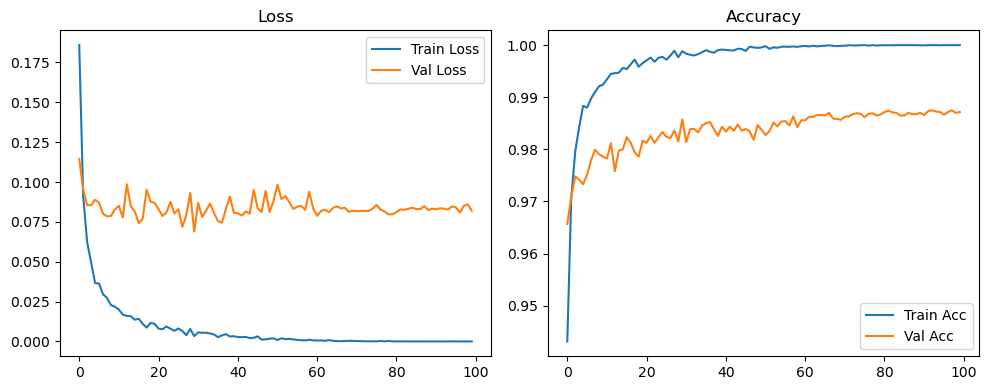

Original Model Final Test Loss: 0.0872 Accuracy: 0.9873




🚀 Running: batch64_lr_max_0.0005_min_1e-05_dp0.05


Training:   0%|                                                                                                                                                                                                     | 0/100 [00:00<?, ?it/s]

| LR: 0.000500 | Train Acc: 0.9408 | Val Acc: 0.9631 | Epoch Time: 0.11 | :   0%|                                                                                                                                   | 0/100 [00:06<?, ?it/s]

| LR: 0.000500 | Train Acc: 0.9408 | Val Acc: 0.9631 | Epoch Time: 0.11 | :   0%|                                                                                                                                   | 0/100 [00:06<?, ?it/s]

...

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.9878 | Epoch Time: 0.06 | :  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊ | 99/100 [06:38<00:03,  3.92s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.9871 | Epoch Time: 0.06 | :  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊ | 99/100 [06:42<00:03,  3.92s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.9871 | Epoch Time: 0.06 | :  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊ | 99/100 [06:42<00:03,  3.92s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.9871 | Epoch Time: 0.06 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [06:42<00:00,  3.92s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.9871 | Epoch Time: 0.06 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [06:42<00:00,  4.02s/it]

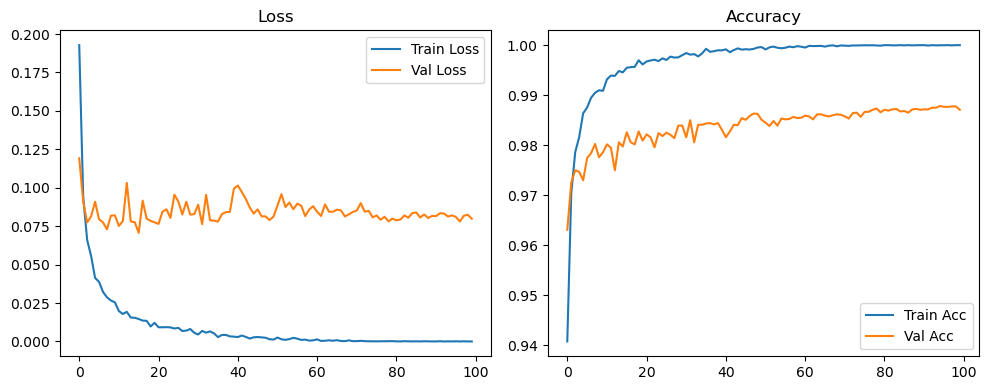

Original Model Final Test Loss: 0.0819 Accuracy: 0.9862




🚀 Running: batch64_lr_max_0.0005_min_1e-05_dp0.1


Training:   0%|                                                                                                                                                                                                     | 0/100 [00:00<?, ?it/s]

| LR: 0.000500 | Train Acc: 0.9396 | Val Acc: 0.9640 | Epoch Time: 0.10 | :   0%|                                                                                                                                   | 0/100 [00:05<?, ?it/s]

| LR: 0.000500 | Train Acc: 0.9396 | Val Acc: 0.9640 | Epoch Time: 0.10 | :   0%|                                                                                                                                   | 0/100 [00:05<?, ?it/s]

...

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.9887 | Epoch Time: 0.07 | :  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊ | 99/100 [06:37<00:03,  3.98s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.9886 | Epoch Time: 0.06 | :  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊ | 99/100 [06:41<00:03,  3.98s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.9886 | Epoch Time: 0.06 | :  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊ | 99/100 [06:41<00:03,  3.98s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.9886 | Epoch Time: 0.06 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [06:41<00:00,  3.97s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.9886 | Epoch Time: 0.06 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [06:41<00:00,  4.01s/it]

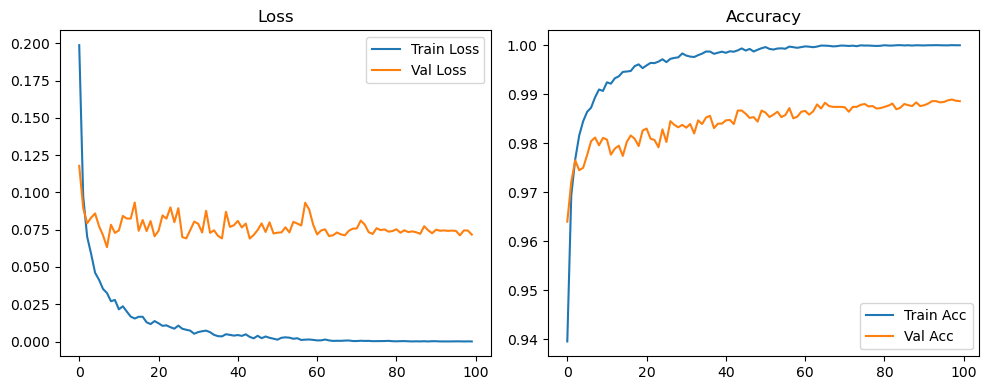

Original Model Final Test Loss: 0.0819 Accuracy: 0.9865




🚀 Running: batch64_lr_max_0.0005_min_1e-06_dp0.0


Training:   0%|                                                                                                                                                                                                     | 0/100 [00:00<?, ?it/s]

| LR: 0.000500 | Train Acc: 0.9431 | Val Acc: 0.9657 | Epoch Time: 0.10 | :   0%|                                                                                                                                   | 0/100 [00:05<?, ?it/s]

| LR: 0.000500 | Train Acc: 0.9431 | Val Acc: 0.9657 | Epoch Time: 0.10 | :   0%|                                                                                                                                   | 0/100 [00:05<?, ?it/s]

...

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9873 | Epoch Time: 0.06 | :  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊ | 99/100 [06:18<00:03,  3.85s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9872 | Epoch Time: 0.07 | :  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊ | 99/100 [06:22<00:03,  3.85s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9872 | Epoch Time: 0.07 | :  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊ | 99/100 [06:22<00:03,  3.85s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9872 | Epoch Time: 0.07 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [06:22<00:00,  3.93s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9872 | Epoch Time: 0.07 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [06:22<00:00,  3.82s/it]

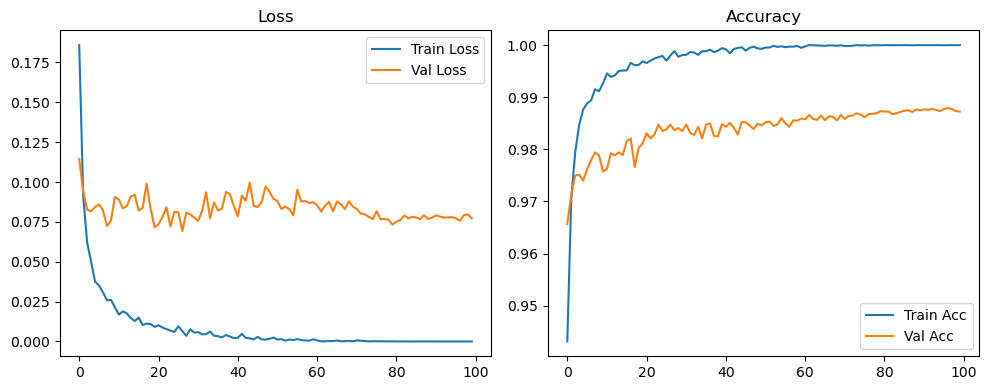

Original Model Final Test Loss: 0.0836 Accuracy: 0.9880




🚀 Running: batch64_lr_max_0.0005_min_1e-06_dp0.05


Training:   0%|                                                                                                                                                                                                     | 0/100 [00:00<?, ?it/s]

| LR: 0.000500 | Train Acc: 0.9408 | Val Acc: 0.9631 | Epoch Time: 0.10 | :   0%|                                                                                                                                   | 0/100 [00:06<?, ?it/s]

| LR: 0.000500 | Train Acc: 0.9408 | Val Acc: 0.9631 | Epoch Time: 0.10 | :   0%|                                                                                                                                   | 0/100 [00:06<?, ?it/s]

...

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9871 | Epoch Time: 0.06 | :  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊ | 99/100 [06:33<00:03,  3.85s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9870 | Epoch Time: 0.06 | :  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊ | 99/100 [06:36<00:03,  3.85s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9870 | Epoch Time: 0.06 | :  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊ | 99/100 [06:36<00:03,  3.85s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9870 | Epoch Time: 0.06 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [06:36<00:00,  3.86s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9870 | Epoch Time: 0.06 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [06:36<00:00,  3.97s/it]

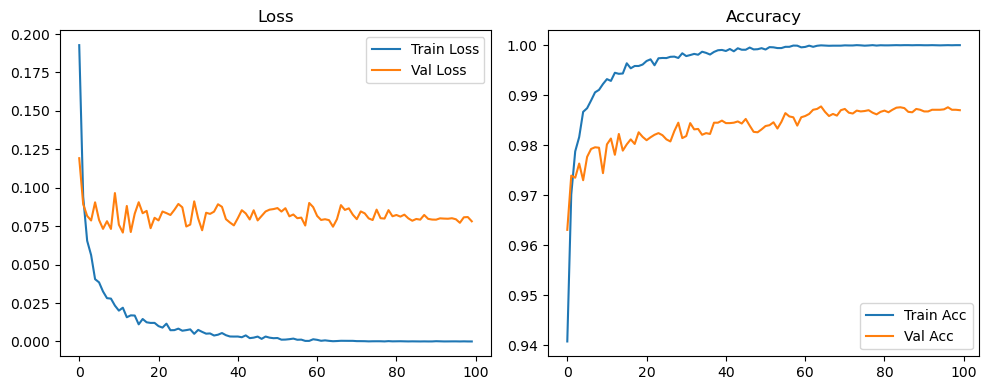

Original Model Final Test Loss: 0.0772 Accuracy: 0.9869




🚀 Running: batch64_lr_max_0.0005_min_1e-06_dp0.1


Training:   0%|                                                                                                                                                                                                     | 0/100 [00:00<?, ?it/s]

| LR: 0.000500 | Train Acc: 0.9396 | Val Acc: 0.9640 | Epoch Time: 0.10 | :   0%|                                                                                                                                   | 0/100 [00:05<?, ?it/s]

| LR: 0.000500 | Train Acc: 0.9396 | Val Acc: 0.9640 | Epoch Time: 0.10 | :   0%|                                                                                                                                   | 0/100 [00:05<?, ?it/s]

...

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9882 | Epoch Time: 0.06 | :  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊ | 99/100 [06:33<00:03,  3.95s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9882 | Epoch Time: 0.06 | :  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊ | 99/100 [06:37<00:03,  3.95s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9882 | Epoch Time: 0.06 | :  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊ | 99/100 [06:37<00:03,  3.95s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9882 | Epoch Time: 0.06 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [06:37<00:00,  3.93s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9882 | Epoch Time: 0.06 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [06:37<00:00,  3.97s/it]

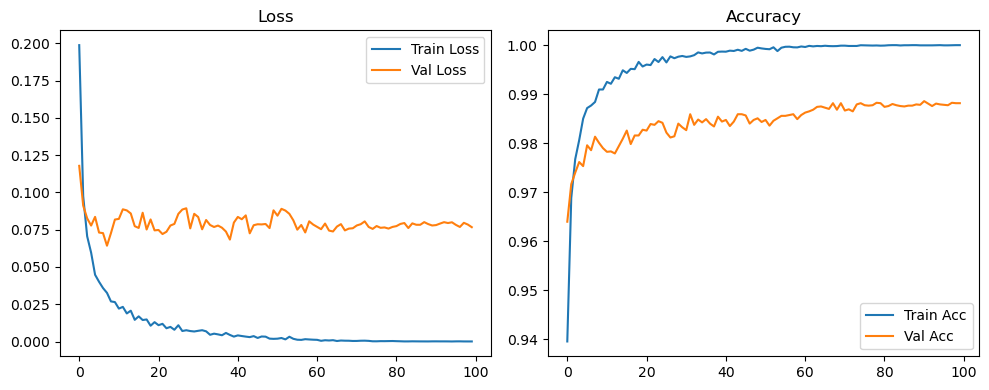

Original Model Final Test Loss: 0.0784 Accuracy: 0.9874




In [17]:
best_epochs, best_batch_size, best_lr_max, best_lr_min, best_dropout, best_resume_path  = Hyperparameter_searching(epochs, batch_sizes, lr_max_pool, lr_min_pool, dropout_rates)

In [18]:
best_evaluation(best_epochs, best_batch_size, best_lr_max, best_lr_min, best_dropout, best_resume_path)

Best model loaded.


Evaluation:   0%|                                                                                                                                                                                                     | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███████████████████████████████████████████████████████████████                                                                                                                              | 1/3 [00:00<00:01,  1.55it/s]

Evaluation:  67%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                                                               | 2/3 [00:01<00:00,  1.52it/s]

Evaluation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:01<00:00,  2.03it/s]

Evaluation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:01<00:00,  1.87it/s]

Best Original Model Final Test Loss: 0.0889 Acc: 0.9881 


